# Fondamentaux : algèbre linéaire, convexité, optimisation

**Notebook 1/9 — Introduction to Supervised Machine Learning**
*M1 MIASHS, M2 MALIA → Master, Guillaume Metzler, Université Lyon 2*

Ce notebook commence par des fondamentaux en mathématiques comme la notion de
norme et de produit scalaire, la convexité (qui garantit qu'un problème de
minimisation « se résout bien »), et les algorithmes de descente qui font
tourner concrètement l'apprentissage. 

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4.5)


## 1. Normes, produit scalaire, valeurs propres

Pour $x, y \in \mathbb{R}^d$, le produit scalaire canonique est
$\langle x,y\rangle = x^Ty = \sum_j x_jy_j$, et la norme euclidienne vérifie
$\|x\|_2^2 = \langle x,x\rangle$. Plus généralement, une **norme** sur un
espace vectoriel $E$ vérifie positivité, homogénéité ($\|\lambda u\| =
|\lambda|\|u\|$) et inégalité triangulaire. Sur $\mathbb{R}^d$, les normes
usuelles sont

$$\|x\|_1=\sum_j|x_j|,\qquad \|x\|_2=\Big(\sum_j x_j^2\Big)^{1/2},\qquad
\|x\|_\infty=\max_j|x_j|.$$

In [4]:
x = np.array([3.0, -4.0, 0.0, 2.0])

print("x =", x)
print("||x||_1   =", np.sum(np.abs(x)), " (numpy:", np.linalg.norm(x, 1), ")")
print("||x||_2   =", np.sqrt(np.sum(x ** 2)), " (numpy:", np.linalg.norm(x, 2), ")")
print("||x||_inf =", np.max(np.abs(x)), " (numpy:", np.linalg.norm(x, np.inf), ")")


x = [ 3. -4.  0.  2.]
||x||_1   = 9.0  (numpy: 9.0 )
||x||_2   = 5.385164807134504  (numpy: 5.385164807134504 )
||x||_inf = 4.0  (numpy: 4.0 )


La **boule unité** $B_p=\{u\in\mathbb{R}^2 : \|u\|_p\leq 1\}$ a une forme
différente selon $p$, un cercle pour $p=2$, un losange pour $p=1$, un carré
pour $p=\infty$, mais dans les trois cas c'est un ensemble **convexe** : le
segment entre deux points de $B_p$ reste dans $B_p$.

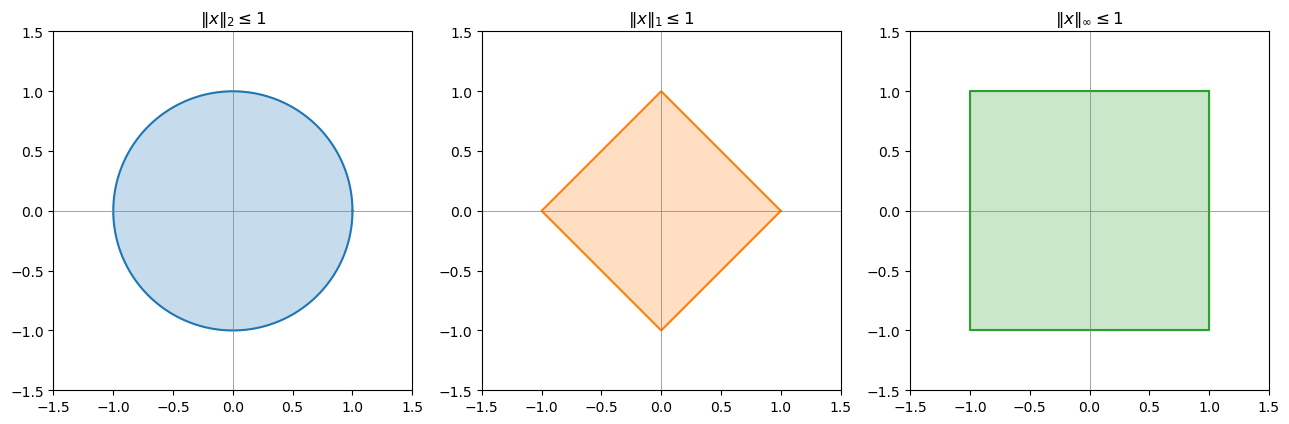

In [5]:
theta = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].plot(np.cos(theta), np.sin(theta), color="tab:blue")
axes[0].fill(np.cos(theta), np.sin(theta), color="tab:blue", alpha=0.25)
axes[0].set_title(r"$\|x\|_2 \leq 1$")

losange = np.array([[1, 0], [0, 1], [-1, 0], [0, -1], [1, 0]], dtype=float)
axes[1].plot(losange[:, 0], losange[:, 1], color="tab:orange")
axes[1].fill(losange[:, 0], losange[:, 1], color="tab:orange", alpha=0.25)
axes[1].set_title(r"$\|x\|_1 \leq 1$")

carre = np.array([[1, 1], [-1, 1], [-1, -1], [1, -1], [1, 1]], dtype=float)
axes[2].plot(carre[:, 0], carre[:, 1], color="tab:green")
axes[2].fill(carre[:, 0], carre[:, 1], color="tab:green", alpha=0.25)
axes[2].set_title(r"$\|x\|_\infty \leq 1$")

for ax in axes:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.tight_layout()
plt.show()


En pratique, on normalise souvent les **colonnes** d'une matrice de données
(une variable par colonne) pour ramener toutes les variables à une échelle
comparable — c'est une étape courante avant d'entraîner beaucoup de modèles
vus dans ce cours.

In [6]:
X_demo = np.array([
    [2.0, 100.0, -1.0],
    [4.0, 300.0, 0.5],
    [1.0, 50.0, 2.0],
    [3.0, 200.0, -0.5],
])

normes_colonnes = np.linalg.norm(X_demo, axis=0)
X_scaled = X_demo / normes_colonnes

print("norme L2 de chaque colonne, avant :", normes_colonnes)
print("norme L2 de chaque colonne, après :", np.linalg.norm(X_scaled, axis=0))


norme L2 de chaque colonne, avant : [  5.47722558 377.49172176   2.34520788]
norme L2 de chaque colonne, après : [1. 1. 1.]


### Exercice 1

On considère la matrice `X` ci-dessous, où chaque **ligne** est cette
fois-ci une observation (6 observations, 4 descripteurs). Normalisez
chaque ligne pour qu'elle ait une norme $L_2$ égale à 1 (sans réutiliser
`X_scaled` : c'est un axe différent), puis vérifiez le résultat.

In [7]:
X = np.array([
    [1.0, 2.0, 2.0, 0.0],
    [3.0, 0.0, 4.0, 0.0],
    [0.0, 5.0, 0.0, 12.0],
    [2.0, 2.0, 1.0, 0.0],
    [1.0, 1.0, 1.0, 1.0],
    [0.0, 0.0, 3.0, 4.0],
])

normes = np.linalg.norm(X, axis=1)
X_normalise = X / normes[:, None]

print("normes avant :", normes)
print("normes après :", np.linalg.norm(X_normalise, axis=1))

assert np.allclose(np.linalg.norm(X_normalise, axis=1), 1.0)
print("Toutes les lignes ont bien une norme L2 unitaire.")


normes avant : [ 3.  5. 13.  3.  2.  5.]
normes après : [1. 1. 1. 1. 1. 1.]
Toutes les lignes ont bien une norme L2 unitaire.


Le produit scalaire sert aussi à mesurer une similarité angulaire entre deux
vecteurs, indépendamment de leur norme : le **cosinus**
$\cos(x,y) = \dfrac{\langle x,y\rangle}{\|x\|_2\|y\|_2}$.

In [8]:
mots = ["chat", "chien", "voiture"]
vecs = np.array([
    [0.9, 0.1, 0.0],
    [0.8, 0.3, 0.0],
    [0.0, 0.0, 1.0],
])


def cosinus(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


for i in range(len(mots)):
    for j in range(i + 1, len(mots)):
        print(f"cos({mots[i]}, {mots[j]}) = {cosinus(vecs[i], vecs[j]):.3f}")


cos(chat, chien) = 0.969
cos(chat, voiture) = 0.000
cos(chien, voiture) = 0.000


### Exercice 2

En reprenant l'idée ci-dessus, calculez, pour les 4 vecteurs `V` donnés
plus bas, la **matrice** des cosinus deux à deux $M_{ij}=\cos(v_i,v_j)$,
sans boucle `for` (utilisez `V @ V.T` et les normes des lignes). Vérifiez
que la diagonale de `M` vaut 1 et que `M` est symétrique.

In [10]:
V = np.array([
    [2.0, 0.0, 1.0, 0.0],
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 3.0, 0.0, 1.0],
    [0.0, 0.0, 2.0, 2.0],
])

normes_V = np.linalg.norm(V, axis=1)
M = (V @ V.T) / np.outer(normes_V, normes_V)

print(np.round(M, 3))

assert np.allclose(np.diag(M), 1.0)
assert np.allclose(M, M.T)
print("Diagonale unitaire et matrice symétrique : cohérent avec la définition du cosinus.")


[[1.    0.632 0.    0.316]
 [0.632 1.    0.671 0.   ]
 [0.    0.671 1.    0.224]
 [0.316 0.    0.224 1.   ]]
Diagonale unitaire et matrice symétrique : cohérent avec la définition du cosinus.


### 1.1 Valeurs propres et vecteurs propres

Un vecteur propre $v\neq 0$ d'une matrice carrée $A$ associé à la valeur
propre $\lambda$ vérifie $Av=\lambda v$. Pour une matrice **symétrique**
réelle, le théorème spectral garantit que toutes les valeurs propres sont
réelles et que les vecteurs propres associés à des valeurs propres
distinctes sont **orthogonaux** — une propriété qu'on va réutiliser
constamment pour les formes quadratiques.

In [ ]:
A_sym = np.array([[4.0, 1.0], [1.0, 3.0]])

valeurs_propres, vecteurs_propres = np.linalg.eigh(A_sym)
print("valeurs propres :", valeurs_propres)
print("vecteurs propres (colonnes) :\n", vecteurs_propres)

for k in range(2):
    v = vecteurs_propres[:, k]
    lam = valeurs_propres[k]
    print(f"||A v_{k} - lambda_{k} v_{k}|| =", np.linalg.norm(A_sym @ v - lam * v))

print("produit scalaire <v0, v1> =", np.dot(vecteurs_propres[:, 0], vecteurs_propres[:, 1]))


In [ ]:
A_nonsym = np.array([[4.0, 1.0], [0.0, 3.0]])

for nom, M in [("symétrique", A_sym), ("non symétrique", A_nonsym)]:
    valeurs, vecteurs = np.linalg.eig(M)
    ps = np.dot(vecteurs[:, 0], vecteurs[:, 1])
    print(f"{nom:15s} : valeurs propres = {valeurs}, <v0,v1> = {ps.real:.4f}")


$$ $$

**Question 1 :** Que remarquez-vous sur le produit scalaire entre les deux vecteurs propres selon que la matrice est symétrique ou non ? Quelle propriété des matrices symétriques réelles cela illustre-t-il ?

$$ $$

*Éléments de réponse.* Pour `A_sym`, le produit scalaire des deux vecteurs propres est (numériquement) nul : ils sont orthogonaux, conformément au théorème spectral pour les matrices symétriques réelles. Pour `A_nonsym`, rien ne garantit cette orthogonalité et le produit scalaire affiché n'est en général pas nul.

## 2. Formes quadratiques et fonctions convexes

À toute matrice symétrique $A\in\mathbb{R}^{d\times d}$ on associe la
**forme quadratique** $q(x) = x^TAx$. Sa nature dépend uniquement du signe
des valeurs propres de $A$ :

- toutes strictement positives $\Rightarrow$ $q$ **définie positive** ($q(x)>0$ pour $x\neq 0$) ;
- toutes strictement négatives $\Rightarrow$ **définie négative** ;
- positives ou nulles (au moins une nulle) $\Rightarrow$ **semi-définie positive** ;
- de signes mélangés $\Rightarrow$ **indéfinie**.

C'est cette même notion, appliquée à la hessienne d'une fonction, qui va
caractériser la convexité.

In [ ]:
def nature_forme_quadratique(A):
    vp = np.linalg.eigvalsh(A)
    if np.all(vp > 1e-10):
        return "définie positive"
    if np.all(vp < -1e-10):
        return "définie négative"
    if np.all(vp >= -1e-10):
        return "semi-définie positive"
    if np.all(vp <= 1e-10):
        return "semi-définie négative"
    return "indéfinie"


A_pos = np.array([[4.0, 3.0], [3.0, 3.0]])        # q(x) = 4x1^2 + 6x1x2 + 3x2^2
A_indef = np.array([[2.0, 5.0, -6.0],
                     [5.0, 6.0, 3.0],
                     [-6.0, 3.0, -1.0]])

for nom, A in [("A_pos", A_pos), ("A_indef", A_indef)]:
    print(f"{nom} : valeurs propres = {np.linalg.eigvalsh(A)}, nature = {nature_forme_quadratique(A)}")


### Exercice 3

Pour les trois matrices `B`, `C`, `D` ci-dessous (toutes symétriques),
déterminez leur nature (définie positive / négative, semi-définie,
indéfinie) en réutilisant `nature_forme_quadratique`.

In [ ]:
B = np.array([[0.0, 3.0, 3.0], [3.0, 2.0, -1.0], [3.0, -1.0, -2.0]])
C = np.array([[0.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 0.0, 1.0]])
D = np.array([[1.0, 1.0], [1.0, 1.0]])

for nom, M in [("B", B), ("C", C), ("D", D)]:
    print(f"{nom} : valeurs propres = {np.linalg.eigvalsh(M)}, nature = {nature_forme_quadratique(M)}")

assert nature_forme_quadratique(D) == "semi-définie positive"
print("Vérifié : D, de rang 1 et à valeurs propres positives ou nulles, est bien semi-définie positive.")


### 2.1 Courbes de niveau et conditionnement

Les courbes de niveau de $q(x)=x^TAx$ sont des ellipses dont l'excentricité
dépend du rapport entre les valeurs propres de $A$ (le **conditionnement**,
$\kappa = \lambda_{\max}/\lambda_{\min}$) : plus il est grand, plus
l'ellipse est allongée.

In [ ]:
def contours_quadratique(A, ax, titre):
    xs = np.linspace(-3, 3, 200)
    ys = np.linspace(-3, 3, 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = A[0, 0] * XX ** 2 + 2 * A[0, 1] * XX * YY + A[1, 1] * YY ** 2
    ax.contour(XX, YY, ZZ, levels=12, cmap="viridis")
    ax.set_aspect("equal")
    ax.set_title(titre)


matrices_vp = {
    "vp = (1, 1)": np.array([[1.0, 0.0], [0.0, 1.0]]),
    "vp = (1, 5)": np.array([[1.0, 0.0], [0.0, 5.0]]),
    "vp = (1, 25)": np.array([[1.0, 0.0], [0.0, 25.0]]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nom, A) in zip(axes, matrices_vp.items()):
    contours_quadratique(A, ax, nom)
plt.tight_layout()
plt.show()


$$ $$

**Question 2 :** Comment les courbes de niveau se déforment-elles quand l'écart entre les deux valeurs propres augmente ? À votre avis, quel effet cela peut-il avoir sur un algorithme qui se déplace dans la direction opposée au gradient, donc perpendiculairement aux courbes de niveau ?

$$ $$

*Éléments de réponse.* Les ellipses s'allongent de plus en plus dans la direction de la petite valeur propre. Un algorithme qui suit le gradient (donc la perpendiculaire locale aux courbes de niveau) va alors « rebondir » d'un bord à l'autre de l'ellipse au lieu d'avancer directement vers le centre : c'est le phénomène de zigzag qu'on observera en section 3 sur les problèmes mal conditionnés.

### 2.2 Fonctions convexes

$f$ est **convexe** sur un ensemble convexe $U$ si, pour tous $u,v\in U$ et
$t\in[0,1]$, $f(tu+(1-t)v)\leq tf(u)+(1-t)f(v)$ : toute corde reliant deux
points du graphe reste au-dessus de la courbe. Si $f$ est deux fois
différentiable, $f$ est convexe sur $U$ (ouvert) si et seulement si sa
hessienne est semi-définie positive **en tout point** de $U$ — exactement
la notion vue en 2.1, appliquée point par point.

In [ ]:
xs = np.linspace(-2.5, 2.5, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

axes[0].plot(xs, xs ** 2, color="tab:blue")
u, v = -1.8, 1.3
t = np.linspace(0, 1, 15)
axes[0].plot(u + t * (v - u), u ** 2 + t * (v ** 2 - u ** 2), "o--", color="tab:orange", ms=3)
axes[0].set_title(r"$f(x)=x^2$ : convexe")

axes[1].plot(xs, xs ** 3 - 3 * xs, color="tab:red")
u2, v2 = -1.6, 1.6
f2 = lambda z: z ** 3 - 3 * z
axes[1].plot(u2 + t * (v2 - u2), f2(u2) + t * (f2(v2) - f2(u2)), "o--", color="tab:orange", ms=3)
axes[1].set_title(r"$f(x)=x^3-3x$ : non convexe")

for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
plt.tight_layout()
plt.show()


In [ ]:
def f_ondule(x):
    x1, x2 = x[..., 0], x[..., 1]
    return 4 + (x1 ** 2 - 2 * np.cos(2 * np.pi * x1)) + (x2 ** 2 - 2 * np.cos(2 * np.pi * x2))


xs = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(xs, xs)
ZZ = f_ondule(np.stack([XX, YY], axis=-1))

plt.figure(figsize=(5.5, 4.5))
cs = plt.contourf(XX, YY, ZZ, levels=30, cmap="viridis")
plt.colorbar(cs)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("f(x1, x2)")
plt.show()


$$ $$

**Question 3 :** Sur le graphique, combien de minima locaux distinguez-vous approximativement sur $[-2,2]^2$ ? Cette fonction est-elle convexe sur ce domaine ? Justifiez en une phrase.

$$ $$

*Éléments de réponse.* On distingue plusieurs minima locaux (aux points de coordonnées entières proches de (±1,0), (0,±1), (±1,±1), en plus du minimum global en (0,0)). Une fonction convexe n'a jamais qu'un seul minimum local (qui est alors automatiquement global) : la présence de plusieurs minima locaux distincts suffit donc à conclure que cette fonction n'est pas convexe sur $[-2,2]^2$.

Pour vérifier la convexité d'une fonction dont on ne connaît pas la
hessienne analytique, on peut l'estimer par différences finies et regarder
son signe sur une grille de points.

In [ ]:
def hessienne_numerique(f, x, eps=1e-4):
    d = len(x)
    H = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            ei = np.zeros(d); ei[i] = eps
            ej = np.zeros(d); ej[j] = eps
            H[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * eps ** 2)
    return H


def convexe_sur_grille(f, bornes, n=15):
    xs = np.linspace(*bornes, n)
    for x1 in xs:
        for x2 in xs:
            H = hessienne_numerique(f, np.array([x1, x2]))
            vp = np.linalg.eigvalsh(H)
            if np.any(vp < -1e-6):
                return False
    return True


def f_test(x):
    x1, x2 = x
    return x1 ** 2 + 3 * x2 ** 2 + 0.5 * np.sin(x1 * x2)


print("f_test est convexe sur [-2,2]^2 :", convexe_sur_grille(f_test, (-2, 2)))


### Exercice 4

En réutilisant `convexe_sur_grille` et `hessienne_numerique`, déterminez si
les deux fonctions suivantes sont convexes sur $[-2,2]^2$ :

- $f_1(x_1,x_2) = x_1^4 - 2x_1^2 + x_2^2$ (un « double puits » selon $x_1$) ;
- $f_2(x_1,x_2) = x_1^2 + 4x_2^2 - 2x_1x_2$ (la forme quadratique de
  l'exercice 3 sur les matrices $2\times 2$, avec `A_pos`).

Pour $f_1$, tracez également ses courbes de niveau pour visualiser
pourquoi elle n'est pas convexe.

In [ ]:
def f1(x):
    x1, x2 = x
    return x1 ** 4 - 2 * x1 ** 2 + x2 ** 2


def f2(x):
    x1, x2 = x
    return x1 ** 2 + 4 * x2 ** 2 - 2 * x1 * x2


print("f1 convexe sur [-2,2]^2 :", convexe_sur_grille(f1, (-2, 2)))
print("f2 convexe sur [-2,2]^2 :", convexe_sur_grille(f2, (-2, 2)))

xs = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(xs, xs)
ZZ1 = XX ** 4 - 2 * XX ** 2 + YY ** 2

plt.figure(figsize=(5.5, 4.5))
cs = plt.contourf(XX, YY, ZZ1, levels=30, cmap="viridis")
plt.colorbar(cs)
plt.title(r"$f_1(x_1,x_2) = x_1^4 - 2x_1^2 + x_2^2$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

print("f1 a deux minima locaux (en x1 = -1 et x1 = +1) : sa non-convexité")
print("est cohérente avec le résultat numérique ci-dessus.")


## 3. Optimisation : conditions d'optimalité et descente de gradient

Minimiser $f$ sur $\mathbb{R}^d$ revient, quand $f$ est différentiable, à
chercher un point où $\nabla f(u)=0$ — l'**équation d'Euler**. C'est une
condition nécessaire mais pas suffisante : le signe des valeurs propres de
la hessienne en un tel point (section 2) tranche ensuite entre minimum,
maximum ou point-selle. En pratique on ne résout presque jamais
$\nabla f(u)=0$ à la main : on construit une suite $(u_k)$ qui avance dans
la direction opposée au gradient,
$$u_{k+1} = u_k - \rho_k \nabla f(u_k),$$
et on arrête dès que $\|\nabla f(u_k)\|\leq \eta$ pour un seuil $\eta$
fixé. Tout l'enjeu est le choix du pas $\rho_k$.

### 3.1 Effet du pas

Sur $f(u) = (u-3)^2$, le pas **optimal** (celui qui minimise exactement $f$
le long du gradient) vaut ici $\rho=1/2$, et on peut comparer son
comportement à un pas trop petit et à un pas trop grand.

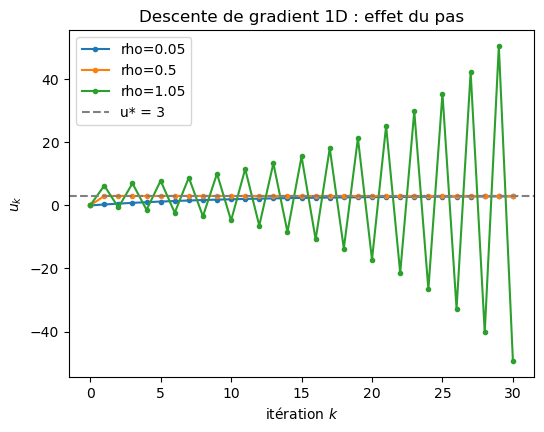

rho=0.05 : u_30 = 2.8728
rho=0.5 : u_30 = 3.0000
rho=1.05 : u_30 = -49.3482


In [13]:
def f1d(u):
    return (u - 3) ** 2


def grad1d(u):
    return 2 * (u - 3)


def descente_1d(u0, rho, n_iter=30):
    u = u0
    traj = [u]
    for _ in range(n_iter):
        u = u - rho * grad1d(u)
        traj.append(u)
    return np.array(traj)


rhos = [0.05, 0.5, 1.05]
plt.figure()
for rho in rhos:
    traj = descente_1d(0.0, rho)
    plt.plot(traj, marker="o", ms=3, label=f"rho={rho}")
plt.axhline(3, color="grey", ls="--", label="u* = 3")
plt.xlabel("itération $k$")
plt.ylabel("$u_k$")
plt.legend()
plt.title("Descente de gradient 1D : effet du pas")
plt.show()

for rho in rhos:
    print(f"rho={rho} : u_30 = {descente_1d(0.0, rho)[-1]:.4f}")


$$ $$

**Question 4 :** Que se passe-t-il pour $\rho=0.05$, $\rho=0.5$ et $\rho=1.05$ ? Sauriez-vous expliquer pourquoi $\rho=0.5$ atteint le minimum en une seule itération pour cette fonction précise ?

$$ $$

*Éléments de réponse.* rho=0.05 converge, mais très lentement (petits pas). rho=0.5 atteint u*=3 en une seule itération. rho=1.05 diverge (la suite oscille avec une amplitude croissante). Pour f(u)=(u-3)^2, la mise à jour s'écrit u_{k+1} = (1-2rho) u_k + 6 rho : avec rho=0.5, le coefficient (1-2rho) vaut exactement 0, donc u_1 = u* quel que soit u_0 (c'est le pas optimal théorique, rho* = 1/f''(u) = 1/2). Dès que |1-2rho| > 1, c'est-à-dire rho > 1, la suite diverge.

### 3.2 Conditionnement et vitesse de convergence

En dimension 2, sur une forme quadratique $f(u)=\tfrac12 u^TAu - b^Tu$, le
gradient est $\nabla f(u) = Au-b$. On reprend les trois matrices `A`
(bien / modérément / mal conditionnées) de la section 2.1, avec le **même**
pas fixe pour les trois, et on regarde le nombre d'itérations.

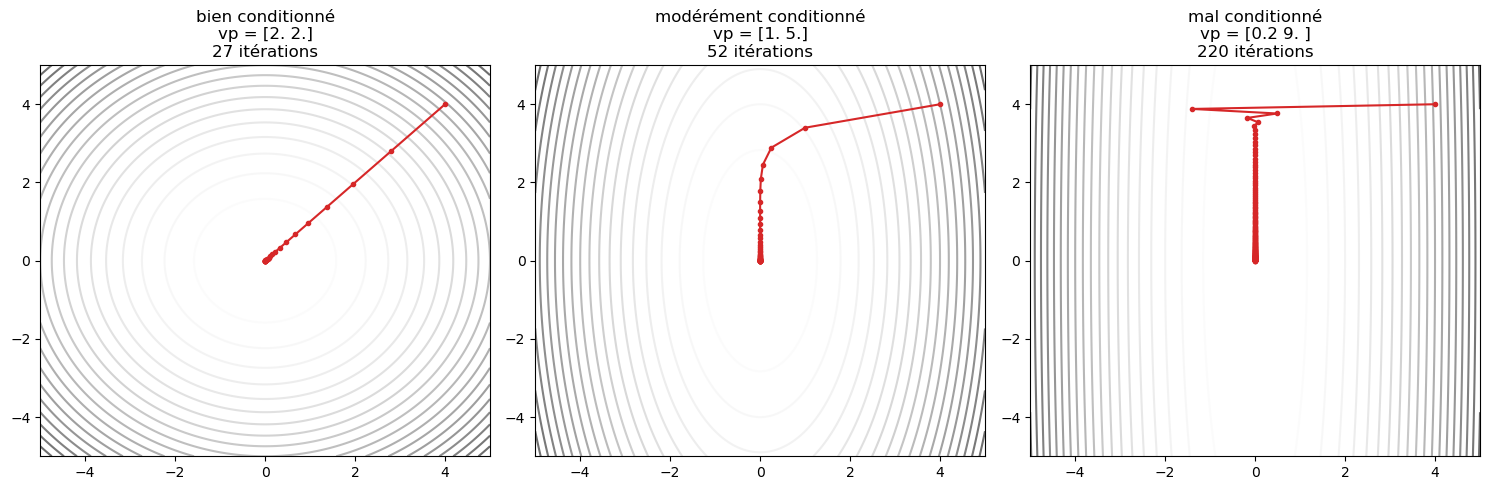

In [14]:
def f_quad(u, A, b):
    return 0.5 * u @ A @ u - b @ u


def grad_quad(u, A, b):
    return A @ u - b


def descente_gradient(A, b, u0, rho, eta=1e-3, n_iter_max=3000):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_iter_max):
        g = grad_quad(u, A, b)
        if np.linalg.norm(g) <= eta:
            break
        u = u - rho * g
        traj.append(u.copy())
    return np.array(traj)


b = np.array([0.0, 0.0])
u0 = np.array([4.0, 4.0])
configs = {
    "bien conditionné": np.array([[2.0, 0.0], [0.0, 2.0]]),
    "modérément conditionné": np.array([[5.0, 0.0], [0.0, 1.0]]),
    "mal conditionné": np.array([[9.0, 0.0], [0.0, 0.2]]),
}

trajectoires = {}
xs = np.linspace(-5, 5, 150)
ys = np.linspace(-5, 5, 150)
XX, YY = np.meshgrid(xs, ys)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nom, A) in zip(axes, configs.items()):
    traj = descente_gradient(A, b, u0, rho=0.15)
    trajectoires[nom] = traj
    ZZ = 0.5 * (A[0, 0] * XX ** 2 + A[1, 1] * YY ** 2)
    ax.contour(XX, YY, ZZ, levels=20, cmap="Greys", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "o-", ms=3, color="tab:red")
    vp = np.linalg.eigvalsh(A)
    ax.set_title(f"{nom}\nvp = {vp}\n{len(traj) - 1} itérations")
plt.tight_layout()
plt.show()


$$ $$

**Question 5 :** Comparez le nombre d'itérations affiché pour les trois cas. Que devient la trajectoire (en rouge) quand le conditionnement se dégrade, et est-ce cohérent avec votre réponse à la question 2 ?

$$ $$

*Éléments de réponse.* Le nombre d'itérations augmente nettement avec le conditionnement (rapport valeur propre max / min) : quelques dizaines d'itérations pour A bien conditionnée, plusieurs centaines pour A mal conditionnée. La trajectoire zigzague de plus en plus entre les deux bords de l'ellipse allongée, exactement le phénomène anticipé à la question 2 : le gradient pointe presque perpendiculairement à l'axe long de l'ellipse plutôt que vers le centre.

### 3.3 Écrire sa propre descente de gradient

On peut généraliser le principe à n'importe quelle fonction (pas seulement
une forme quadratique), en gardant la même mécanique : pas fixe et
critère d'arrêt sur la norme du gradient.

In [15]:
# Meme mecanique que descente_gradient, mais en dimension 3
A3 = np.array([[3.0, 0.0, 0.0], [0.0, 2.0, 0.0], [0.0, 0.0, 1.0]])
b3 = np.array([1.0, 1.0, 1.0])
u0_3 = np.zeros(3)

traj3 = descente_gradient(A3, b3, u0_3, rho=0.2, eta=1e-6, n_iter_max=1000)
u_star3 = np.linalg.solve(A3, b3)

print("minimum théorique  :", u_star3)
print("point atteint       :", traj3[-1])
print("nombre d'itérations :", len(traj3) - 1)


minimum théorique  : [0.33333333 0.5        1.        ]
point atteint       : [0.33333333 0.5        0.99999902]
nombre d'itérations : 62


### Exercice 5

Écrivez une version générique `descente_gradient_generique(f, grad_f, u0,
rho, eta=1e-6, n_iter_max=5000)`, qui accepte n'importe quelle fonction `f`
et son gradient `grad_f` (pas seulement `f_quad`/`grad_quad`), avec le même
critère d'arrêt sur $\|\nabla f(u_k)\|$. Utilisez-la pour minimiser
l'objectif des moindres carrés $g(\theta) = \|X\theta - y\|_2^2$, pour une
matrice `X` simulée (20 observations, 3 descripteurs) et
$y = X\theta_{\text{vrai}} + \text{bruit}$. Comparez le $\theta$ trouvé à
la solution analytique $(X^TX)^{-1}X^Ty$.

*(Indice : pour garantir la convergence, choisissez un pas
$\rho \leq 1/\lambda_{\max}(2X^TX)$, où $2X^TX$ est la hessienne de $g$.)*

In [16]:
def descente_gradient_generique(f, grad_f, u0, rho, eta=1e-6, n_iter_max=5000):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_iter_max):
        g = grad_f(u)
        if np.linalg.norm(g) <= eta:
            break
        u = u - rho * g
        traj.append(u.copy())
    return np.array(traj)


n, d = 20, 3
X = np.random.randn(n, d)
theta_vrai = np.array([2.0, -1.0, 0.5])
y = X @ theta_vrai + 0.1 * np.random.randn(n)


def g_mc(theta):
    return np.sum((X @ theta - y) ** 2)


def grad_g_mc(theta):
    return 2 * X.T @ (X @ theta - y)


L = np.max(np.linalg.eigvalsh(2 * X.T @ X))
rho = 1.0 / L

traj_theta = descente_gradient_generique(g_mc, grad_g_mc, np.zeros(d), rho=rho, eta=1e-4, n_iter_max=5000)
theta_gd = traj_theta[-1]
theta_analytique = np.linalg.solve(X.T @ X, X.T @ y)

print("theta trouvé par descente de gradient :", theta_gd)
print("theta analytique (X^TX)^-1 X^Ty       :", theta_analytique)
print("nombre d'itérations                    :", len(traj_theta) - 1)

assert np.allclose(theta_gd, theta_analytique, atol=1e-2)
print("Cohérent : la descente de gradient converge vers la solution analytique des moindres carrés.")


theta trouvé par descente de gradient : [ 1.98587277 -0.96921545  0.51019675]
theta analytique (X^TX)^-1 X^Ty       : [ 1.98587296 -0.96921626  0.51019777]
nombre d'itérations                    : 13
Cohérent : la descente de gradient converge vers la solution analytique des moindres carrés.


### 3.4 Pas optimal

Pour une forme quadratique, le pas optimal $\rho_k = \arg\min_{\rho>0}
f(u_k-\rho\nabla f(u_k))$ a une expression fermée :
$$\rho_k = \frac{\|\nabla f(u_k)\|_2^2}{\nabla f(u_k)^T A \nabla f(u_k)}.$$

In [17]:
def descente_gradient_optimal(A, b, u0, eta=1e-3, n_iter_max=3000):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_iter_max):
        g = grad_quad(u, A, b)
        if np.linalg.norm(g) <= eta:
            break
        rho_k = (g @ g) / (g @ A @ g)
        u = u - rho_k * g
        traj.append(u.copy())
    return np.array(traj)


A_modere = configs["modérément conditionné"]
traj_fixe_modere = trajectoires["modérément conditionné"]
traj_opt_modere = descente_gradient_optimal(A_modere, b, u0)

print("pas fixe (rho=0.15) :", len(traj_fixe_modere) - 1, "itérations")
print("pas optimal          :", len(traj_opt_modere) - 1, "itérations")


pas fixe (rho=0.15) : 52 itérations
pas optimal          : 9 itérations


### Exercice 6

En reprenant `descente_gradient_optimal` et le dictionnaire `configs`,
appliquez-la à la matrice **mal conditionnée**
(`configs["mal conditionné"]`), et comparez le nombre d'itérations obtenu
à celui du pas fixe déjà stocké dans `trajectoires["mal conditionné"]`.
Affichez les deux trajectoires sur les mêmes courbes de niveau.

pas fixe (rho=0.15) : 220 itérations
pas optimal          : 5 itérations


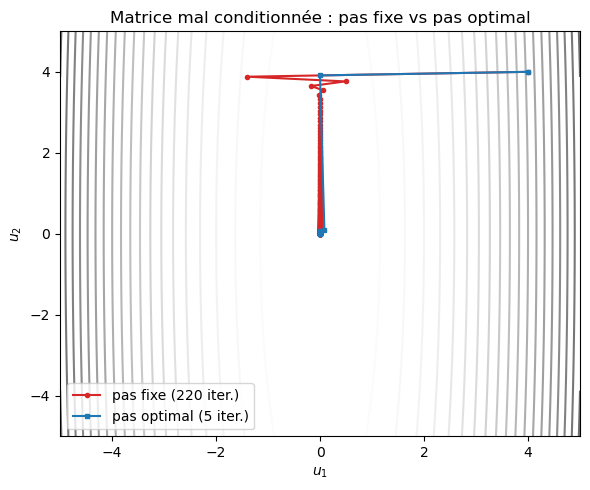


Le pas optimal réduit spectaculairement le nombre d'itérations par
rapport au pas fixe : en recalculant à chaque étape le pas qui
minimise exactement f le long du gradient, la recherche linéaire
exacte absorbe l'essentiel du zigzag que provoquait le pas fixe sur
ce problème mal conditionné. Sur un problème non quadratique en
revanche (Rosenbrock, exercice 7), il n'existe pas de formule fermée
pour ce pas optimal.


In [18]:
A_mal = configs["mal conditionné"]
traj_fixe_mal = trajectoires["mal conditionné"]
traj_opt_mal = descente_gradient_optimal(A_mal, b, u0)

print("pas fixe (rho=0.15) :", len(traj_fixe_mal) - 1, "itérations")
print("pas optimal          :", len(traj_opt_mal) - 1, "itérations")

xs = np.linspace(-5, 5, 150)
ys = np.linspace(-5, 5, 150)
XX, YY = np.meshgrid(xs, ys)
ZZ = 0.5 * (A_mal[0, 0] * XX ** 2 + A_mal[1, 1] * YY ** 2)

plt.figure(figsize=(6, 5))
plt.contour(XX, YY, ZZ, levels=20, cmap="Greys", alpha=0.6)
plt.plot(traj_fixe_mal[:, 0], traj_fixe_mal[:, 1], "o-", ms=3, color="tab:red",
         label=f"pas fixe ({len(traj_fixe_mal) - 1} iter.)")
plt.plot(traj_opt_mal[:, 0], traj_opt_mal[:, 1], "s-", ms=3, color="tab:blue",
         label=f"pas optimal ({len(traj_opt_mal) - 1} iter.)")
plt.xlabel("$u_1$")
plt.ylabel("$u_2$")
plt.title("Matrice mal conditionnée : pas fixe vs pas optimal")
plt.legend()
plt.tight_layout()
plt.show()

print()
print("Le pas optimal réduit spectaculairement le nombre d'itérations par")
print("rapport au pas fixe : en recalculant à chaque étape le pas qui")
print("minimise exactement f le long du gradient, la recherche linéaire")
print("exacte absorbe l'essentiel du zigzag que provoquait le pas fixe sur")
print("ce problème mal conditionné. Sur un problème non quadratique en")
print("revanche (Rosenbrock, exercice 7), il n'existe pas de formule fermée")
print("pour ce pas optimal.")


### 3.5 Comparaison avec `scipy.optimize`

En pratique, on réimplémente rarement soi-même une descente de gradient :
`scipy.optimize.minimize` propose des méthodes plus robustes (BFGS,
gradient conjugué...), et on peut suivre leur trajectoire via l'option
`callback`.

In [ ]:
from scipy.optimize import minimize

A_scipy = configs["modérément conditionné"]


def f_scipy(u):
    return f_quad(u, A_scipy, b)


def grad_scipy(u):
    return grad_quad(u, A_scipy, b)


trajectoire_bfgs = [u0.copy()]


def callback(xk):
    trajectoire_bfgs.append(np.array(xk))


res = minimize(f_scipy, u0, jac=grad_scipy, method="BFGS", callback=callback)
print("scipy BFGS : nit =", res.nit, ", solution =", res.x)
print("(à comparer aux", len(trajectoires["modérément conditionné"]) - 1,
      "itérations de notre pas fixe rho=0.15)")


### Exercice 7 (ouvert)

La fonction de **Rosenbrock**
$f(x_1,x_2)=(1-x_1)^2+100(x_2-x_1^2)^2$ a un unique minimum global en
$(1,1)$, mais une vallée étroite et très courbée qui la rend difficile
pour une descente de gradient à pas fixe. En partant de $u_0=(-1.5, 2)$ :

1. implémentez `rosenbrock` et son gradient `grad_rosenbrock` (les deux
   dérivées partielles sont $-2(1-x_1)-400x_1(x_2-x_1^2)$ et
   $200(x_2-x_1^2)$) ;
2. lancez `descente_gradient_generique` (celle de l'exercice 5) avec un
   pas fixe assez petit (`rho=0.001`) ;
3. comparez le nombre d'itérations à `scipy.optimize.minimize` avec
   `method="BFGS"` puis `method="CG"` (en fournissant le gradient et un
   `callback`) ;
4. affichez les trois trajectoires sur les courbes de niveau (échelle log
   conseillée, `levels=np.logspace(...)`).

In [ ]:
def rosenbrock(x):
    x1, x2 = x[0], x[1]
    return (1 - x1) ** 2 + 100 * (x2 - x1 ** 2) ** 2


def grad_rosenbrock(x):
    x1, x2 = x[0], x[1]
    dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1 ** 2)
    dx2 = 200 * (x2 - x1 ** 2)
    return np.array([dx1, dx2])


u0_rosen = np.array([-1.5, 2.0])

traj_gd = descente_gradient_generique(rosenbrock, grad_rosenbrock, u0_rosen,
                                       rho=0.001, eta=1e-3, n_iter_max=20000)

resultats = {}
for methode in ["BFGS", "CG"]:
    traj_m = [u0_rosen.copy()]

    def cb(xk, traj=traj_m):
        traj.append(np.array(xk))

    res = minimize(rosenbrock, u0_rosen, jac=grad_rosenbrock, method=methode, callback=cb)
    resultats[methode] = {"trajectoire": np.array(traj_m), "nit": res.nit, "x": res.x}

print("descente de gradient (pas fixe) :", len(traj_gd) - 1, "itérations, point final =", traj_gd[-1])
for methode, res in resultats.items():
    print(f"{methode:6s} : nit = {res['nit']:4d}, solution = {res['x']}")
    assert np.allclose(res["x"], [1.0, 1.0], atol=1e-2)

xs = np.linspace(-2, 2, 300)
ys = np.linspace(-1, 3, 300)
XX, YY = np.meshgrid(xs, ys)
ZZ = (1 - XX) ** 2 + 100 * (YY - XX ** 2) ** 2

plt.figure(figsize=(6.5, 5.3))
plt.contourf(XX, YY, ZZ, levels=np.logspace(-0.5, 3.5, 25), cmap="Greys",
             norm=matplotlib.colors.LogNorm(), alpha=0.6)
plt.plot(traj_gd[:, 0], traj_gd[:, 1], "-", lw=1, color="tab:red",
         label=f"pas fixe ({len(traj_gd) - 1} iter.)")
couleurs = {"BFGS": "tab:blue", "CG": "tab:orange"}
for methode, res in resultats.items():
    traj_m = res["trajectoire"]
    plt.plot(traj_m[:, 0], traj_m[:, 1], "o-", ms=3, color=couleurs[methode],
              label=f"{methode} ({res['nit']} iter.)")
plt.plot(1, 1, "g*", ms=16, label="minimum global (1,1)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Rosenbrock : pas fixe vs BFGS vs CG")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print()
print("La descente de gradient a pas fixe a besoin d'un ordre de grandeur")
print("(voire plusieurs) de plus d'itérations que BFGS ou CG pour atteindre")
print("le minimum : ces méthodes exploitent une approximation de la courbure")
print("(BFGS) ou une meilleure direction de descente (CG), là où notre pas")
print("fixe se contente de suivre le gradient avec un pas prudent et constant.")


## Pour aller plus loin

Normes, produit scalaire, valeurs propres, formes quadratiques, convexité
et descente de gradient : ce sont les briques qu'on retrouvera à chaque
notebook suivant, la régression (moindres carrés, exercice 5) et la
régression logistique se formulent comme des minimisations convexes, les
SVM comme une optimisation sous contraintes convexes, et l'entraînement des
réseaux de neurones repose sur des variantes stochastiques de la descente
de gradient. Une autre décomposition matricielle très utilisée en
apprentissage, la **décomposition en valeurs singulières (SVD)**, généralise
la diagonalisation par valeurs propres aux matrices non carrées ; on la
retrouvera dans un notebook consacré à la réduction de dimension.